# 훈련 데이터 vs 검증/테스트 데이터 비교


- 질문 길이 차이
- 문서 길이 차이
- title 주제 분포 차이
- answer 길이 차이


In [2]:
import os
import sys

# OpenMP 라이브러리 충돌 해결
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_from_disk
from collections import Counter

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# 현재 디렉토리 확인 및 경로 설정
print(f"현재 작업 디렉토리: {os.getcwd()}")

# 데이터 로드
train_dataset = load_from_disk("../../data/train_dataset")
test_dataset = load_from_disk("../../data/test_dataset")

print("\n=== 훈련 데이터셋 ===")
print(train_dataset)
print("\n=== 테스트 데이터셋 ===")
print(test_dataset)

# 데이터프레임으로 변환
train_df = pd.DataFrame(train_dataset["train"])
val_df = pd.DataFrame(train_dataset["validation"])
test_df = pd.DataFrame(test_dataset["validation"])

print(f"\n훈련 데이터: {len(train_df)}개")
print(f"검증 데이터: {len(val_df)}개")
print(f"테스트 데이터: {len(test_df)}개")


현재 작업 디렉토리: d:\Repos\pro-nlp-mrc-nlp-01\notebooks\EDA

=== 훈련 데이터셋 ===
DatasetDict({
    train: Dataset({
        features: ['title', 'context', 'question', 'id', 'answers', 'document_id', '__index_level_0__'],
        num_rows: 3952
    })
    validation: Dataset({
        features: ['title', 'context', 'question', 'id', 'answers', 'document_id', '__index_level_0__'],
        num_rows: 240
    })
})

=== 테스트 데이터셋 ===
DatasetDict({
    validation: Dataset({
        features: ['question', 'id'],
        num_rows: 600
    })
})

훈련 데이터: 3952개
검증 데이터: 240개
테스트 데이터: 600개


## 1. 질문 길이 차이


=== 질문 길이 통계 ===

훈련 데이터:
count    3952.000000
mean       29.322368
std         8.727421
min         8.000000
25%        23.000000
50%        29.000000
75%        35.000000
max        78.000000
Name: question_length, dtype: float64

검증 데이터:
count    240.000000
mean      29.195833
std        8.728301
min        9.000000
25%       23.000000
50%       29.000000
75%       35.000000
max       59.000000
Name: question_length, dtype: float64

테스트 데이터:
count    600.000000
mean      29.555000
std        8.962376
min        8.000000
25%       23.000000
50%       29.000000
75%       35.000000
max       62.000000
Name: question_length, dtype: float64


C:\Users\pilla\AppData\Local\Temp\ipykernel_25960\23835339.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_to_plot, labels=['Train', 'Validation', 'Test'])


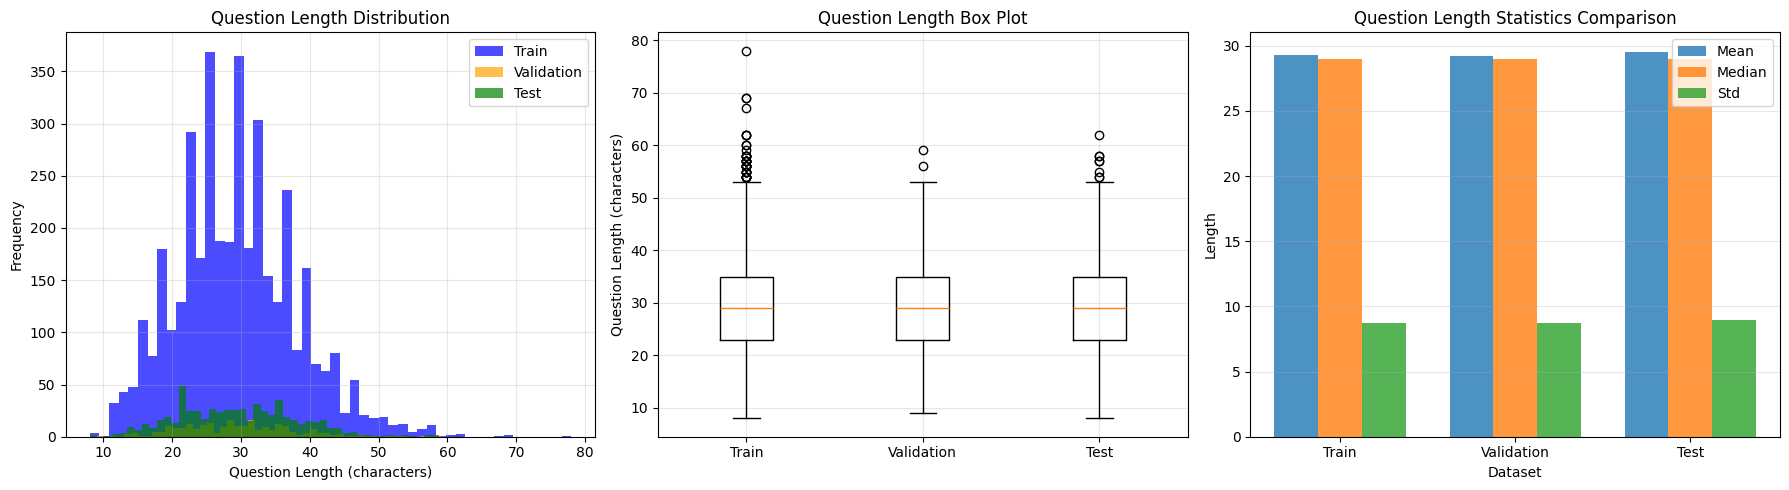

In [3]:
# 질문 길이 계산 (문자 수 기준)
train_df['question_length'] = train_df['question'].str.len()
val_df['question_length'] = val_df['question'].str.len()
test_df['question_length'] = test_df['question'].str.len()

# 통계 정보
print("=== 질문 길이 통계 ===")
print("\n훈련 데이터:")
print(train_df['question_length'].describe())
print("\n검증 데이터:")
print(val_df['question_length'].describe())
print("\n테스트 데이터:")
print(test_df['question_length'].describe())

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 히스토그램
axes[0].hist(train_df['question_length'], bins=50, alpha=0.7, label='Train', color='blue')
axes[0].hist(val_df['question_length'], bins=50, alpha=0.7, label='Validation', color='orange')
axes[0].hist(test_df['question_length'], bins=50, alpha=0.7, label='Test', color='green')
axes[0].set_xlabel('Question Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Question Length Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 박스플롯
data_to_plot = [train_df['question_length'], val_df['question_length'], test_df['question_length']]
axes[1].boxplot(data_to_plot, labels=['Train', 'Validation', 'Test'])
axes[1].set_ylabel('Question Length (characters)')
axes[1].set_title('Question Length Box Plot')
axes[1].grid(True, alpha=0.3)

# 통계 비교 바 차트
stats_data = {
    'Train': [train_df['question_length'].mean(), train_df['question_length'].median(), train_df['question_length'].std()],
    'Validation': [val_df['question_length'].mean(), val_df['question_length'].median(), val_df['question_length'].std()],
    'Test': [test_df['question_length'].mean(), test_df['question_length'].median(), test_df['question_length'].std()]
}
x = np.arange(3)
width = 0.25
axes[2].bar(x - width, [stats_data['Train'][0], stats_data['Validation'][0], stats_data['Test'][0]], 
            width, label='Mean', alpha=0.8)
axes[2].bar(x, [stats_data['Train'][1], stats_data['Validation'][1], stats_data['Test'][1]], 
            width, label='Median', alpha=0.8)
axes[2].bar(x + width, [stats_data['Train'][2], stats_data['Validation'][2], stats_data['Test'][2]], 
            width, label='Std', alpha=0.8)
axes[2].set_xlabel('Dataset')
axes[2].set_ylabel('Length')
axes[2].set_title('Question Length Statistics Comparison')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Train', 'Validation', 'Test'])
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 2. 문서 길이 차이


테스트 데이터에는 context가 없습니다.
=== 문서 길이 통계 ===

훈련 데이터:
count    3952.000000
mean      920.220648
std       356.500514
min       512.000000
25%       645.000000
50%       819.000000
75%      1099.250000
max      2059.000000
Name: context_length, dtype: float64

검증 데이터:
count     240.000000
mean      916.725000
std       360.032122
min       517.000000
25%       616.750000
50%       820.500000
75%      1107.250000
max      2064.000000
Name: context_length, dtype: float64


C:\Users\pilla\AppData\Local\Temp\ipykernel_25960\489429834.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_to_plot, labels=['Train', 'Validation'])


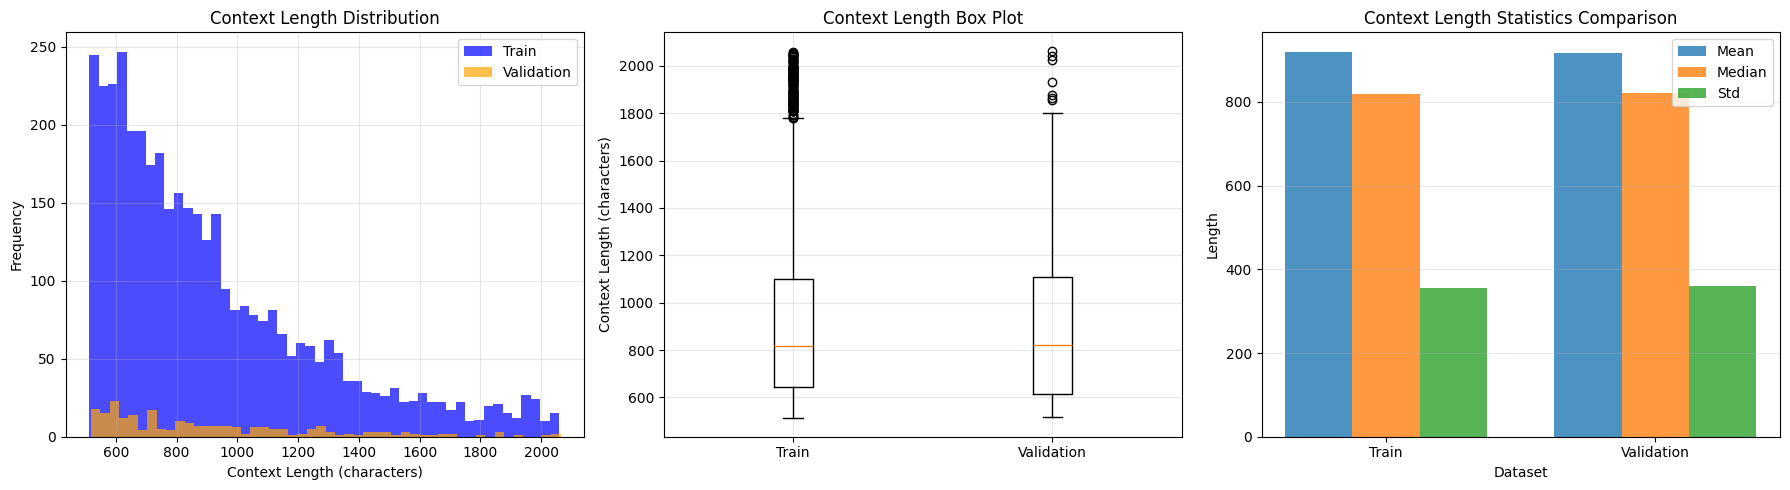

In [5]:
# 문서 길이 계산 (문자 수 기준)
train_df['context_length'] = train_df['context'].str.len()
val_df['context_length'] = val_df['context'].str.len()

# 테스트 데이터에는 context가 없을 수 있으므로 확인
if 'context' in test_df.columns:
    test_df['context_length'] = test_df['context'].str.len()
    has_test_context = True
else:
    has_test_context = False
    print("테스트 데이터에는 context가 없습니다.")

# 통계 정보
print("=== 문서 길이 통계 ===")
print("\n훈련 데이터:")
print(train_df['context_length'].describe())
print("\n검증 데이터:")
print(val_df['context_length'].describe())
if has_test_context:
    print("\n테스트 데이터:")
    print(test_df['context_length'].describe())

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 히스토그램
axes[0].hist(train_df['context_length'], bins=50, alpha=0.7, label='Train', color='blue')
axes[0].hist(val_df['context_length'], bins=50, alpha=0.7, label='Validation', color='orange')
if has_test_context:
    axes[0].hist(test_df['context_length'], bins=50, alpha=0.7, label='Test', color='green')
axes[0].set_xlabel('Context Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Context Length Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 박스플롯
if has_test_context:
    data_to_plot = [train_df['context_length'], val_df['context_length'], test_df['context_length']]
    axes[1].boxplot(data_to_plot, labels=['Train', 'Validation', 'Test'])
else:
    data_to_plot = [train_df['context_length'], val_df['context_length']]
    axes[1].boxplot(data_to_plot, labels=['Train', 'Validation'])
axes[1].set_ylabel('Context Length (characters)')
axes[1].set_title('Context Length Box Plot')
axes[1].grid(True, alpha=0.3)

# 통계 비교 바 차트
if has_test_context:
    stats_data = {
        'Train': [train_df['context_length'].mean(), train_df['context_length'].median(), train_df['context_length'].std()],
        'Validation': [val_df['context_length'].mean(), val_df['context_length'].median(), val_df['context_length'].std()],
        'Test': [test_df['context_length'].mean(), test_df['context_length'].median(), test_df['context_length'].std()]
    }
    x = np.arange(3)
    labels = ['Train', 'Validation', 'Test']
else:
    stats_data = {
        'Train': [train_df['context_length'].mean(), train_df['context_length'].median(), train_df['context_length'].std()],
        'Validation': [val_df['context_length'].mean(), val_df['context_length'].median(), val_df['context_length'].std()]
    }
    x = np.arange(2)
    labels = ['Train', 'Validation']

width = 0.25
axes[2].bar(x - width, [stats_data['Train'][0], stats_data['Validation'][0]] + ([stats_data['Test'][0]] if has_test_context else []), 
            width, label='Mean', alpha=0.8)
axes[2].bar(x, [stats_data['Train'][1], stats_data['Validation'][1]] + ([stats_data['Test'][1]] if has_test_context else []), 
            width, label='Median', alpha=0.8)
axes[2].bar(x + width, [stats_data['Train'][2], stats_data['Validation'][2]] + ([stats_data['Test'][2]] if has_test_context else []), 
            width, label='Std', alpha=0.8)
axes[2].set_xlabel('Dataset')
axes[2].set_ylabel('Length')
axes[2].set_title('Context Length Statistics Comparison')
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 3. Title 주제 분포 차이


=== Title 분포 통계 ===

훈련 데이터 고유 title 수: 2716
검증 데이터 고유 title 수: 228

훈련 데이터 상위 10개 title:
title
윤치호            43
장면             24
여운형            23
데카메론의 줄거리      13
루트비히 비트겐슈타인    13
근대             13
강희제            11
이오 (위성)        11
미치류            11
박근혜 정부         10
Name: count, dtype: int64

검증 데이터 상위 10개 title:
title
교황 비오 11세    2
티칼           2
레닌주의         2
나치 독일        2
로마 군단        2
자수장          2
태양권계면        2
김준연          2
송나라          2
데카메론의 줄거리    2
Name: count, dtype: int64

훈련-검증 공통 title 수: 120


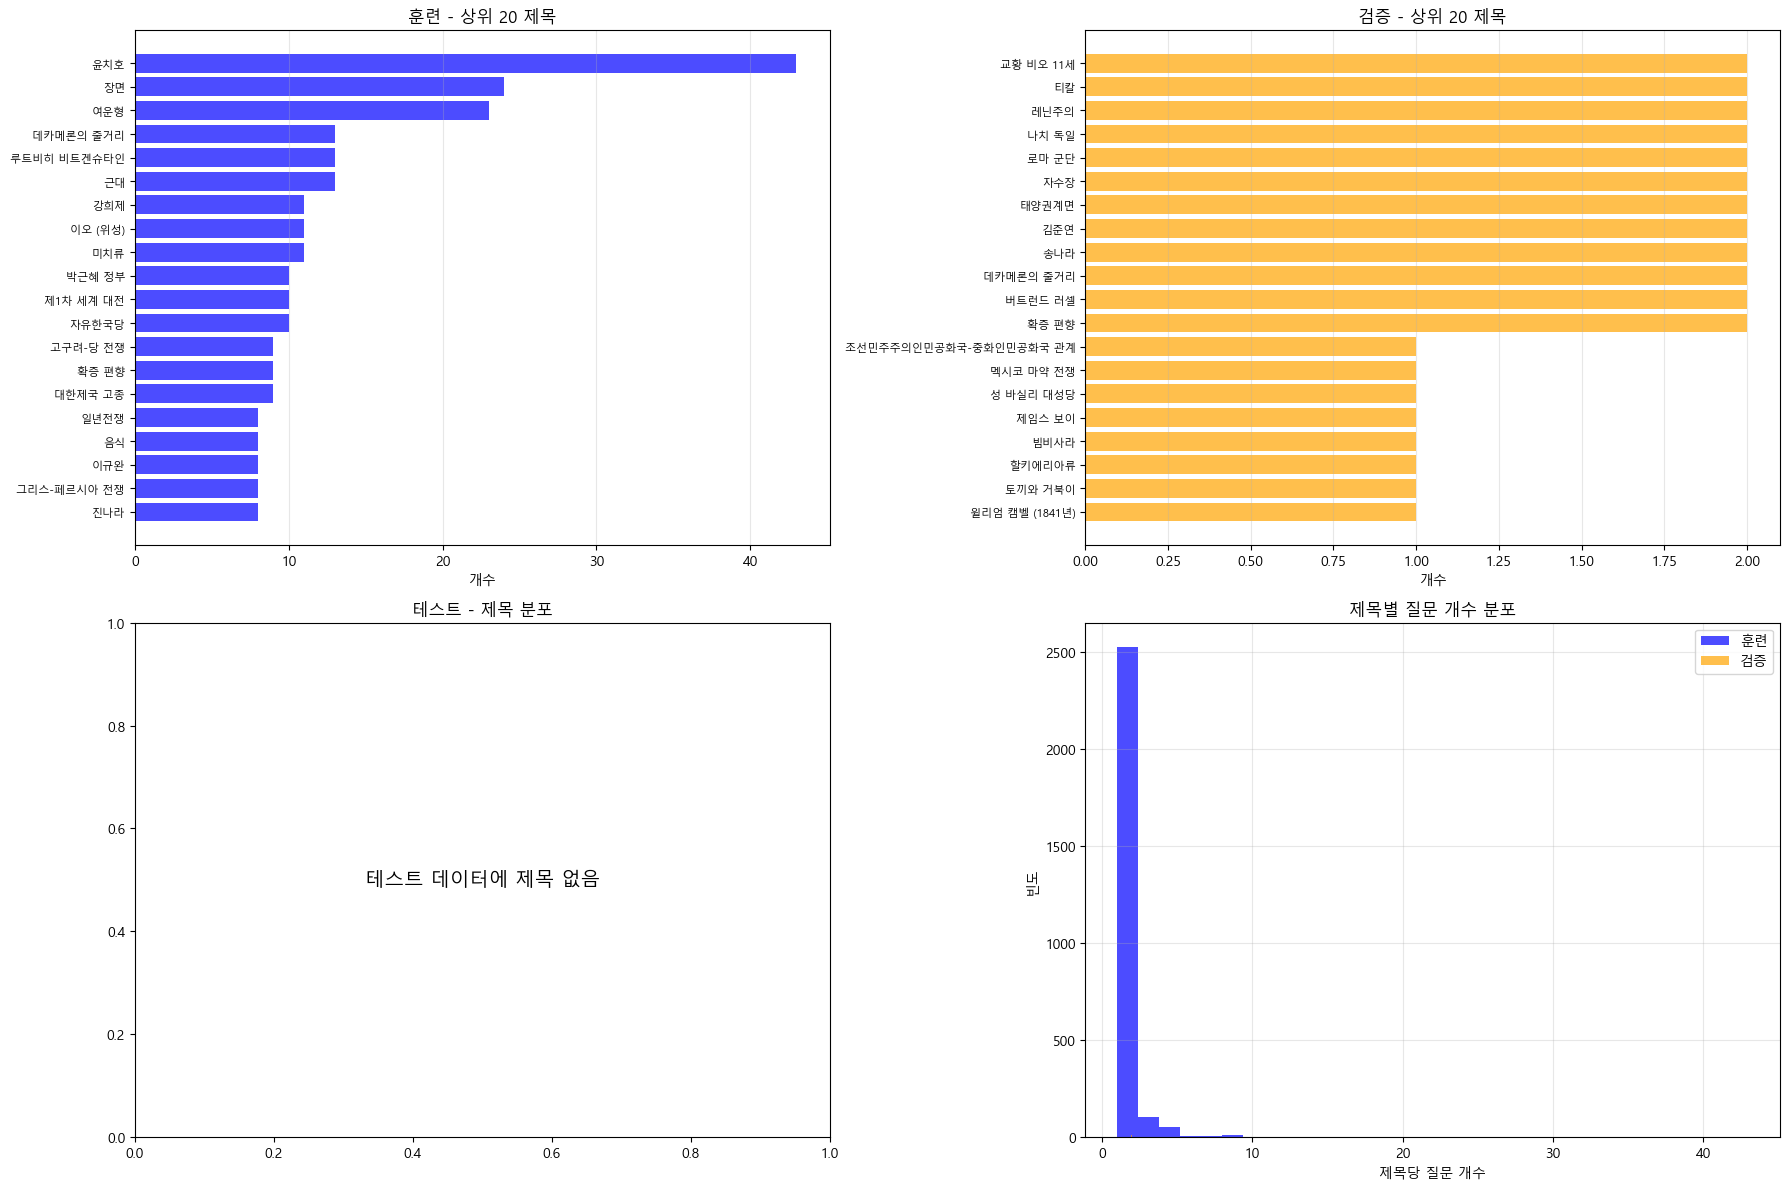

In [7]:
# 한글 깨짐 방지: 폰트 설정 (나눔고딕이 설치되어 있으면 사용, 없으면 기본 폰트)
import matplotlib
from matplotlib import font_manager, rc

def set_korean_font():
    import platform
    os_name = platform.system()
    if os_name == 'Windows':
        font_paths = font_manager.findSystemFonts(fontpaths=None, fontext='ttf')
        nanum_fonts = [f for f in font_paths if 'NanumGothic' in f]
        if nanum_fonts:
            font_path = nanum_fonts[0]
            font_name = font_manager.FontProperties(fname=font_path).get_name()
            rc('font', family=font_name)
        else:
            rc('font', family='Malgun Gothic')
    elif os_name == 'Darwin':
        rc('font', family='AppleGothic')
    else:
        # 리눅스 (colab/ubuntu 등) 기본
        font_paths = font_manager.findSystemFonts(fontpaths=None, fontext='ttf')
        nanum_fonts = [f for f in font_paths if 'NanumGothic' in f]
        if nanum_fonts:
            font_path = nanum_fonts[0]
            font_name = font_manager.FontProperties(fname=font_path).get_name()
            rc('font', family=font_name)
        else:
            rc('font', family='DejaVu Sans')

    matplotlib.rcParams['axes.unicode_minus'] = False # 마이너스 깨짐 방지

set_korean_font()

# Title 분포 확인
train_titles = train_df['title'].value_counts()
val_titles = val_df['title'].value_counts()
test_titles = test_df['title'].value_counts() if 'title' in test_df.columns else pd.Series()

print("=== Title 분포 통계 ===")
print(f"\n훈련 데이터 고유 title 수: {train_df['title'].nunique()}")
print(f"검증 데이터 고유 title 수: {val_df['title'].nunique()}")
if 'title' in test_df.columns:
    print(f"테스트 데이터 고유 title 수: {test_df['title'].nunique()}")

print(f"\n훈련 데이터 상위 10개 title:")
print(train_titles.head(10))
print(f"\n검증 데이터 상위 10개 title:")
print(val_titles.head(10))
if 'title' in test_df.columns and len(test_titles) > 0:
    print(f"\n테스트 데이터 상위 10개 title:")
    print(test_titles.head(10))

# 공통 title 확인
common_train_val = set(train_df['title'].unique()) & set(val_df['title'].unique())
print(f"\n훈련-검증 공통 title 수: {len(common_train_val)}")
if 'title' in test_df.columns:
    common_train_test = set(train_df['title'].unique()) & set(test_df['title'].unique())
    common_val_test = set(val_df['title'].unique()) & set(test_df['title'].unique())
    print(f"훈련-테스트 공통 title 수: {len(common_train_test)}")
    print(f"검증-테스트 공통 title 수: {len(common_val_test)}")

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Top 20 title 분포 비교
top_n = 20
top_train = train_titles.head(top_n)
top_val = val_titles.head(top_n)
if 'title' in test_df.columns and len(test_titles) > 0:
    top_test = test_titles.head(top_n)

axes[0, 0].barh(range(len(top_train)), top_train.values, alpha=0.7, color='blue')
axes[0, 0].set_yticks(range(len(top_train)))
axes[0, 0].set_yticklabels(top_train.index, fontsize=8)
axes[0, 0].set_xlabel('개수')
axes[0, 0].set_title(f'훈련 - 상위 {top_n} 제목')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(True, alpha=0.3, axis='x')

axes[0, 1].barh(range(len(top_val)), top_val.values, alpha=0.7, color='orange')
axes[0, 1].set_yticks(range(len(top_val)))
axes[0, 1].set_yticklabels(top_val.index, fontsize=8)
axes[0, 1].set_xlabel('개수')
axes[0, 1].set_title(f'검증 - 상위 {top_n} 제목')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(True, alpha=0.3, axis='x')

if 'title' in test_df.columns and len(test_titles) > 0:
    axes[1, 0].barh(range(len(top_test)), top_test.values, alpha=0.7, color='green')
    axes[1, 0].set_yticks(range(len(top_test)))
    axes[1, 0].set_yticklabels(top_test.index, fontsize=8)
    axes[1, 0].set_xlabel('개수')
    axes[1, 0].set_title(f'테스트 - 상위 {top_n} 제목')
    axes[1, 0].invert_yaxis()
    axes[1, 0].grid(True, alpha=0.3, axis='x')
else:
    axes[1, 0].text(0.5, 0.5, '테스트 데이터에 제목 없음', 
                    ha='center', va='center', transform=axes[1, 0].transAxes, fontsize=14)
    axes[1, 0].set_title('테스트 - 제목 분포')

# Title 개수 분포
title_counts_train = train_titles.values
title_counts_val = val_titles.values
if 'title' in test_df.columns and len(test_titles) > 0:
    title_counts_test = test_titles.values

axes[1, 1].hist(title_counts_train, bins=30, alpha=0.7, label='훈련', color='blue')
axes[1, 1].hist(title_counts_val, bins=30, alpha=0.7, label='검증', color='orange')
if 'title' in test_df.columns and len(test_titles) > 0:
    axes[1, 1].hist(title_counts_test, bins=30, alpha=0.7, label='테스트', color='green')
axes[1, 1].set_xlabel('제목당 질문 개수')
axes[1, 1].set_ylabel('빈도')
axes[1, 1].set_title('제목별 질문 개수 분포')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Answer 길이 차이


테스트 데이터에는 answers가 없습니다.
=== Answer 길이 통계 ===

훈련 데이터:
count    3952.000000
mean        6.275051
std         5.346842
min         1.000000
25%         3.000000
50%         5.000000
75%         8.000000
max        83.000000
Name: answer_length, dtype: float64

검증 데이터:
count    240.000000
mean       6.912500
std        6.858755
min        1.000000
25%        3.000000
50%        5.000000
75%        8.000000
max       64.000000
Name: answer_length, dtype: float64


C:\Users\pilla\AppData\Local\Temp\ipykernel_25960\3435803060.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_to_plot, labels=['Train', 'Validation'])


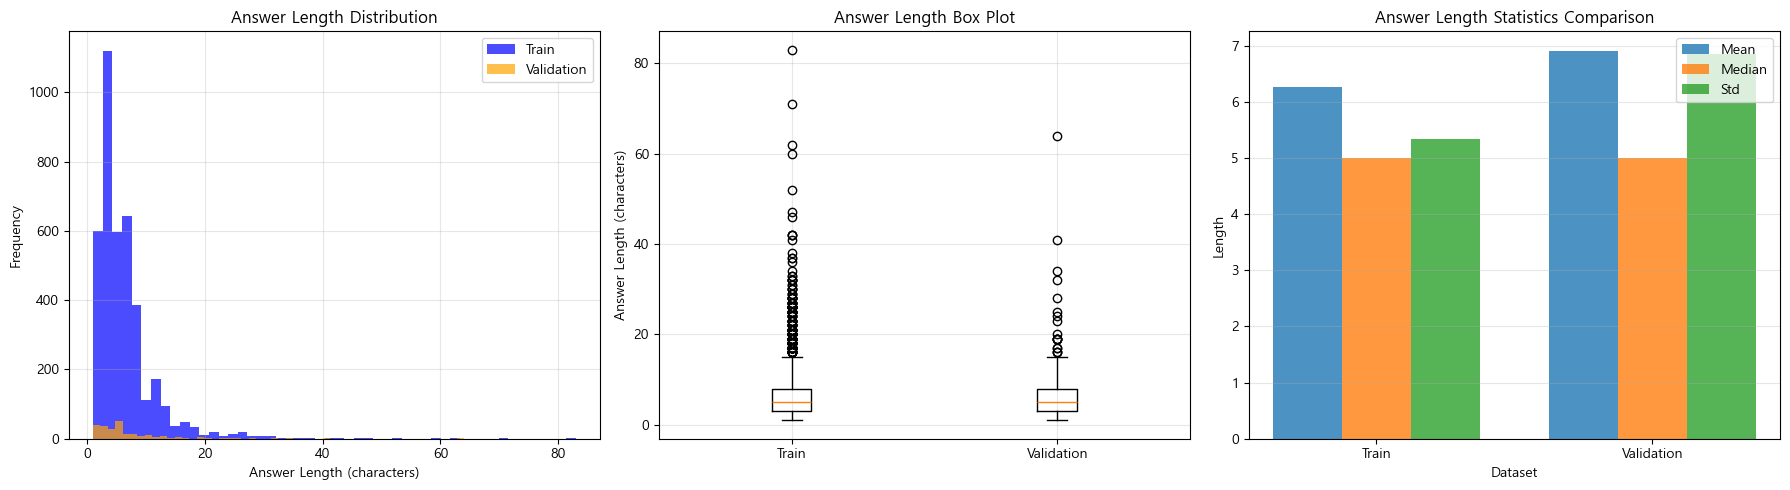

In [8]:
# Answer 길이 계산
def get_answer_length(answers):
    """answers 딕셔너리에서 텍스트 길이 추출"""
    if isinstance(answers, dict) and 'text' in answers:
        # 여러 답변이 있을 수 있으므로 첫 번째 답변의 길이 사용
        if len(answers['text']) > 0:
            return len(answers['text'][0])
    return 0

train_df['answer_length'] = train_df['answers'].apply(get_answer_length)
val_df['answer_length'] = val_df['answers'].apply(get_answer_length)

# 테스트 데이터에는 answers가 없을 수 있으므로 확인
if 'answers' in test_df.columns:
    test_df['answer_length'] = test_df['answers'].apply(get_answer_length)
    has_test_answers = True
else:
    has_test_answers = False
    print("테스트 데이터에는 answers가 없습니다.")

# 통계 정보
print("=== Answer 길이 통계 ===")
print("\n훈련 데이터:")
print(train_df['answer_length'].describe())
print("\n검증 데이터:")
print(val_df['answer_length'].describe())
if has_test_answers:
    print("\n테스트 데이터:")
    print(test_df['answer_length'].describe())

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 히스토그램
axes[0].hist(train_df['answer_length'], bins=50, alpha=0.7, label='Train', color='blue')
axes[0].hist(val_df['answer_length'], bins=50, alpha=0.7, label='Validation', color='orange')
if has_test_answers:
    axes[0].hist(test_df['answer_length'], bins=50, alpha=0.7, label='Test', color='green')
axes[0].set_xlabel('Answer Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Answer Length Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 박스플롯
if has_test_answers:
    data_to_plot = [train_df['answer_length'], val_df['answer_length'], test_df['answer_length']]
    axes[1].boxplot(data_to_plot, labels=['Train', 'Validation', 'Test'])
else:
    data_to_plot = [train_df['answer_length'], val_df['answer_length']]
    axes[1].boxplot(data_to_plot, labels=['Train', 'Validation'])
axes[1].set_ylabel('Answer Length (characters)')
axes[1].set_title('Answer Length Box Plot')
axes[1].grid(True, alpha=0.3)

# 통계 비교 바 차트
if has_test_answers:
    stats_data = {
        'Train': [train_df['answer_length'].mean(), train_df['answer_length'].median(), train_df['answer_length'].std()],
        'Validation': [val_df['answer_length'].mean(), val_df['answer_length'].median(), val_df['answer_length'].std()],
        'Test': [test_df['answer_length'].mean(), test_df['answer_length'].median(), test_df['answer_length'].std()]
    }
    x = np.arange(3)
    labels = ['Train', 'Validation', 'Test']
else:
    stats_data = {
        'Train': [train_df['answer_length'].mean(), train_df['answer_length'].median(), train_df['answer_length'].std()],
        'Validation': [val_df['answer_length'].mean(), val_df['answer_length'].median(), val_df['answer_length'].std()]
    }
    x = np.arange(2)
    labels = ['Train', 'Validation']

width = 0.25
axes[2].bar(x - width, [stats_data['Train'][0], stats_data['Validation'][0]] + ([stats_data['Test'][0]] if has_test_answers else []), 
            width, label='Mean', alpha=0.8)
axes[2].bar(x, [stats_data['Train'][1], stats_data['Validation'][1]] + ([stats_data['Test'][1]] if has_test_answers else []), 
            width, label='Median', alpha=0.8)
axes[2].bar(x + width, [stats_data['Train'][2], stats_data['Validation'][2]] + ([stats_data['Test'][2]] if has_test_answers else []), 
            width, label='Std', alpha=0.8)
axes[2].set_xlabel('Dataset')
axes[2].set_ylabel('Length')
axes[2].set_title('Answer Length Statistics Comparison')
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 요약 통계 비교


In [9]:
# 전체 통계 요약 테이블
summary_data = {
    'Metric': ['Question Length (mean)', 'Question Length (median)', 
               'Context Length (mean)', 'Context Length (median)',
               'Answer Length (mean)', 'Answer Length (median)',
               'Unique Titles', 'Total Samples'],
    'Train': [
        train_df['question_length'].mean(),
        train_df['question_length'].median(),
        train_df['context_length'].mean(),
        train_df['context_length'].median(),
        train_df['answer_length'].mean(),
        train_df['answer_length'].median(),
        train_df['title'].nunique(),
        len(train_df)
    ],
    'Validation': [
        val_df['question_length'].mean(),
        val_df['question_length'].median(),
        val_df['context_length'].mean(),
        val_df['context_length'].median(),
        val_df['answer_length'].mean(),
        val_df['answer_length'].median(),
        val_df['title'].nunique(),
        len(val_df)
    ]
}

if 'title' in test_df.columns:
    summary_data['Test'] = [
        test_df['question_length'].mean(),
        test_df['question_length'].median(),
        test_df['context_length'].mean() if 'context_length' in test_df.columns else None,
        test_df['context_length'].median() if 'context_length' in test_df.columns else None,
        test_df['answer_length'].mean() if 'answer_length' in test_df.columns else None,
        test_df['answer_length'].median() if 'answer_length' in test_df.columns else None,
        test_df['title'].nunique(),
        len(test_df)
    ]

summary_df = pd.DataFrame(summary_data)
print("=== 전체 통계 요약 ===")
print(summary_df.to_string(index=False))

# 차이 계산 (Train vs Validation)
print("\n=== 훈련 vs 검증 차이 ===")
print(f"질문 길이 평균 차이: {abs(train_df['question_length'].mean() - val_df['question_length'].mean()):.2f}")
print(f"문서 길이 평균 차이: {abs(train_df['context_length'].mean() - val_df['context_length'].mean()):.2f}")
print(f"답변 길이 평균 차이: {abs(train_df['answer_length'].mean() - val_df['answer_length'].mean()):.2f}")
print(f"Title 공통 비율: {len(common_train_val) / max(train_df['title'].nunique(), val_df['title'].nunique()) * 100:.2f}%")


=== 전체 통계 요약 ===
                  Metric       Train  Validation
  Question Length (mean)   29.322368   29.195833
Question Length (median)   29.000000   29.000000
   Context Length (mean)  920.220648  916.725000
 Context Length (median)  819.000000  820.500000
    Answer Length (mean)    6.275051    6.912500
  Answer Length (median)    5.000000    5.000000
           Unique Titles 2716.000000  228.000000
           Total Samples 3952.000000  240.000000

=== 훈련 vs 검증 차이 ===
질문 길이 평균 차이: 0.13
문서 길이 평균 차이: 3.50
답변 길이 평균 차이: 0.64
Title 공통 비율: 4.42%
